### SmartCart Customer Clustering

In [152]:
#importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [153]:
df=pd.read_csv("smartcart_customers.csv")

In [154]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [156]:
df.shape

(2240, 22)

In [157]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

### Data Preprocessing

In [158]:
#lowercasing all attributes values of dataset

df.columns = df.columns.str.lower()

In [159]:
# replacing null value in income with its median

df['income'] = df['income'].fillna(df['income'].median())

In [160]:
df.isnull().sum()

id                     0
year_birth             0
education              0
marital_status         0
income                 0
kidhome                0
teenhome               0
dt_customer            0
recency                0
mntwines               0
mntfruits              0
mntmeatproducts        0
mntfishproducts        0
mntsweetproducts       0
mntgoldprods           0
numdealspurchases      0
numwebpurchases        0
numcatalogpurchases    0
numstorepurchases      0
numwebvisitsmonth      0
complain               0
response               0
dtype: int64

### Feature engineering

In [161]:
df.columns

Index(['id', 'year_birth', 'education', 'marital_status', 'income', 'kidhome',
       'teenhome', 'dt_customer', 'recency', 'mntwines', 'mntfruits',
       'mntmeatproducts', 'mntfishproducts', 'mntsweetproducts',
       'mntgoldprods', 'numdealspurchases', 'numwebpurchases',
       'numcatalogpurchases', 'numstorepurchases', 'numwebvisitsmonth',
       'complain', 'response'],
      dtype='object')

In [162]:
#Customer tenure Feature

df['dt_customer'] = pd.to_datetime(df['dt_customer'],dayfirst=True)

df['cutomer_tenure'] = (df['dt_customer'].max() - df['dt_customer']).dt.days

In [163]:
#age columns from year of birth

df['age'] = 2026 - df['year_birth']

In [164]:
#total spending 

df['total_spending'] = df['mntwines'] + df['mntfruits'] + df['mntmeatproducts'] + df['mntfishproducts'] + df['mntsweetproducts'] + df['mntgoldprods']

In [165]:
df['education'].value_counts()

education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [166]:
#education 

df['education'] = df['education'].replace({
    "Graduation":"Graduate",
    "2n Cycle":"UnderGraduate",
    "Basic":"UnderGraduate",
    "Master":"PostGraduate",
    "PhD":"PostGraduate",
})

In [167]:
df['education'].value_counts()

education
Graduate         1127
PostGraduate      856
UnderGraduate     257
Name: count, dtype: int64

In [168]:
df['marital_status'].value_counts()

marital_status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [169]:
# Marital Status

df["living_with"] = df["marital_status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Alone", "Divorced": "Alone",
    "Widow": "Alone", "Absurd": "Alone", "YOLO": "Alone"
})

In [170]:
#children 

df['total_children'] = df['kidhome'] + df['teenhome']

In [171]:
df.head()

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,numcatalogpurchases,numstorepurchases,numwebvisitsmonth,complain,response,cutomer_tenure,age,total_spending,living_with,total_children
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,663,69,1617,Alone,0
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,113,72,27,Alone,2
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,312,61,776,Partner,0
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,139,42,53,Partner,1
4,5324,1981,PostGraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,161,45,422,Partner,1


### droping columns

In [172]:
#drop columns -> df_cleaned

cols = ["id", "year_birth", "marital_status", "kidhome", "teenhome", "dt_customer"]
spending_cols = ["mntwines", "mntfruits", "mntmeatproducts", "mntfishproducts", "mntsweetproducts", "mntgoldprods"]

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [173]:
df_cleaned.shape

(2240, 15)

In [174]:
df_cleaned.head()

,education,income,recency,numdealspurchases,numwebpurchases,numcatalogpurchases,numstorepurchases,numwebvisitsmonth,complain,response,cutomer_tenure,age,total_spending,living_with,total_children
0,Graduate,58138.0,58,3,8,10,4,7,0,1,663,69,1617,Alone,0
1,Graduate,46344.0,38,2,1,1,2,5,0,0,113,72,27,Alone,2
2,Graduate,71613.0,26,1,8,2,10,4,0,0,312,61,776,Partner,0
3,Graduate,26646.0,26,2,2,0,4,6,0,0,139,42,53,Partner,1
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,161,45,422,Partner,1


#### visulising the data

### 1 handling outliers

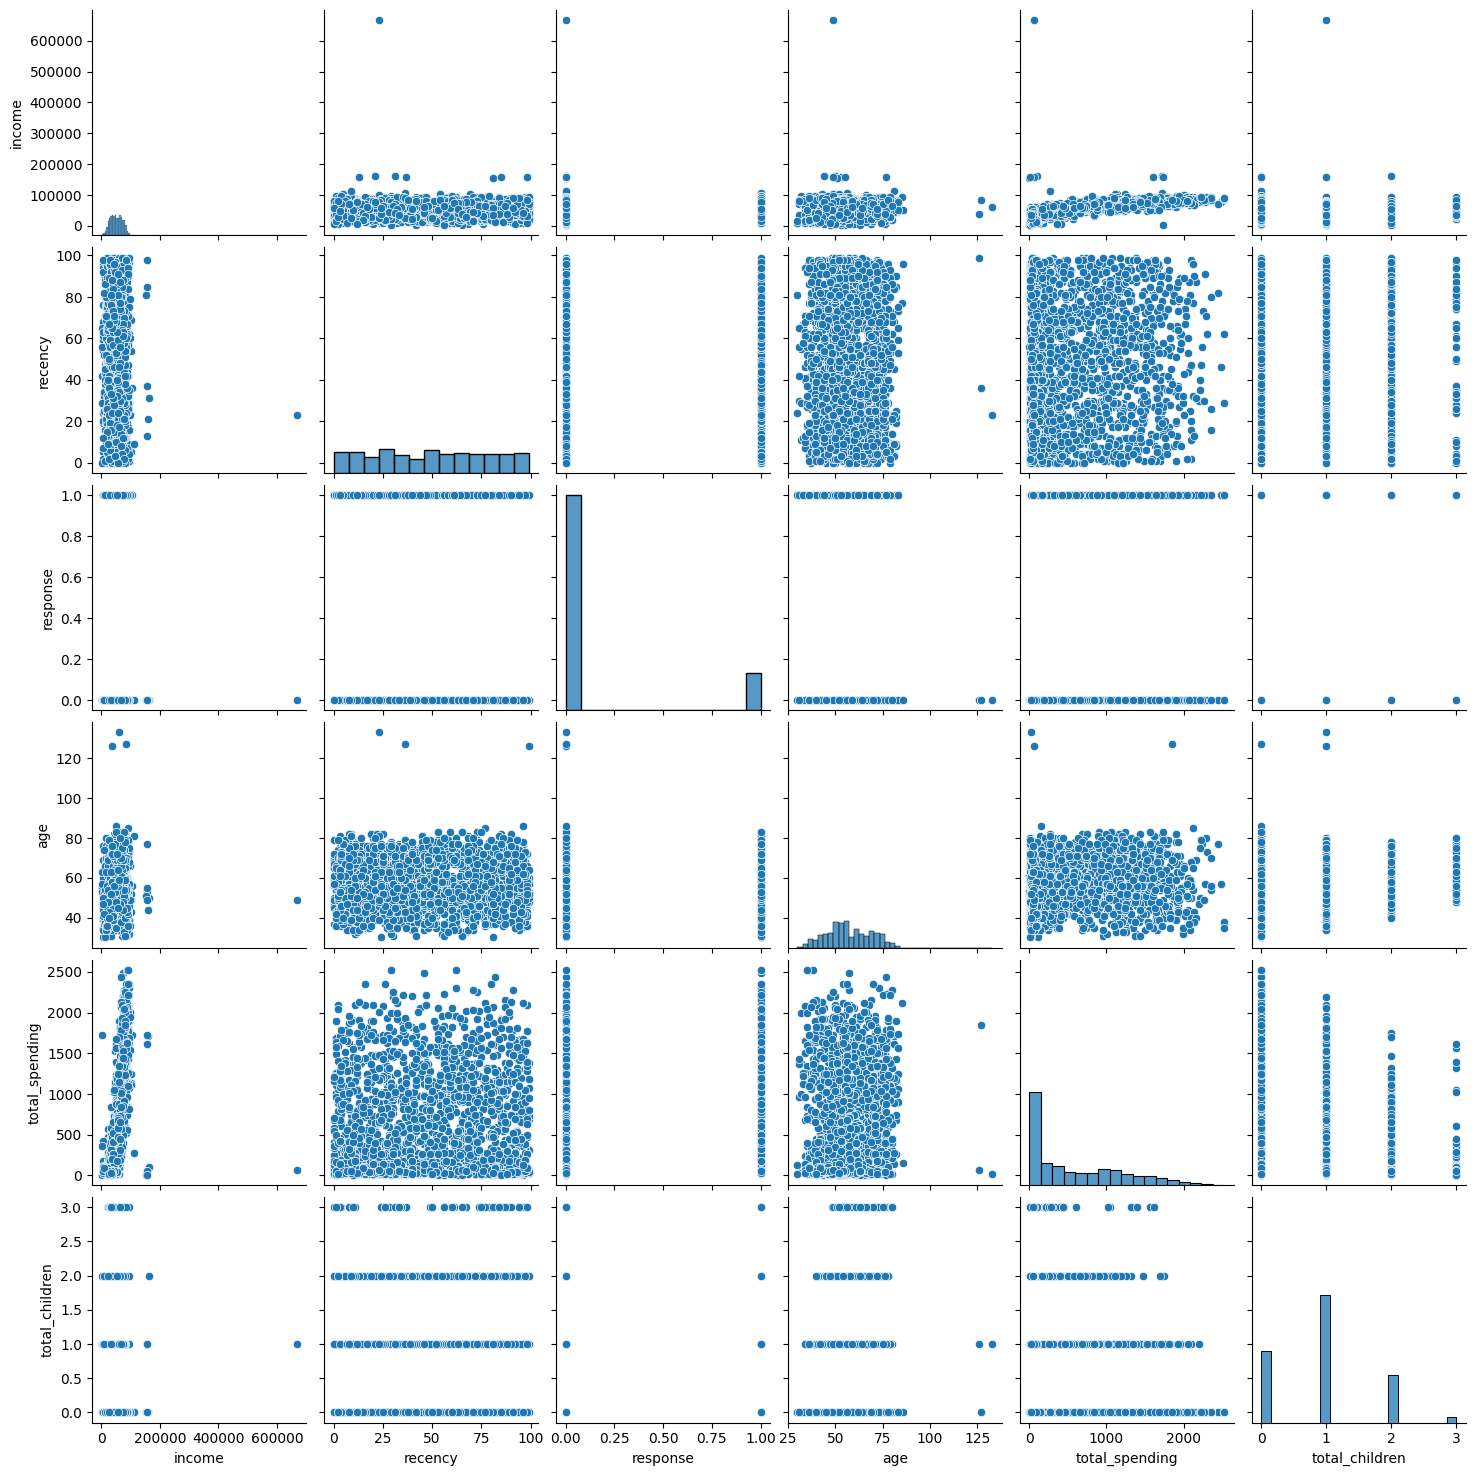

In [175]:
#pair plot

cols = ["income", "recency", "response", "age", "total_spending", "total_children"]

sns.pairplot(df_cleaned[cols])

In [176]:
#removing outliers

df_cleaned = df_cleaned[ (df_cleaned['age']<100) ]
df_cleaned = df_cleaned[ (df_cleaned['income'] <600000) ]

df_cleaned.shape[0]

2236

### 2 Heatmap

In [177]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

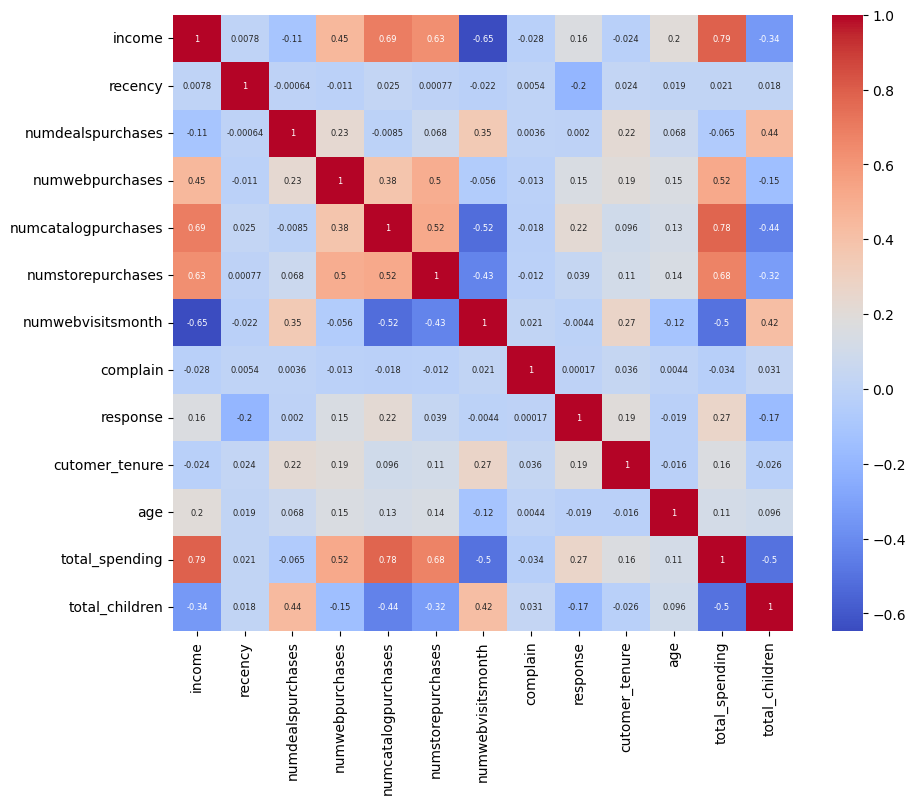

In [178]:
#heatmap
plt.figure(figsize=(10,8))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            annot_kws={"size": 6})

### Feature Encoding

In [179]:
#one hot encoding

one = OneHotEncoder()

cat_features = ["education", "living_with"]

enc_cols = one.fit_transform(df_cleaned[cat_features])

In [180]:
enc_df = pd.DataFrame(enc_cols.toarray(),columns=one.get_feature_names_out(cat_features),index=df_cleaned.index)

In [181]:
#adding encoded feature 

df_encoded = pd.concat([df_cleaned.drop(columns=cat_features),enc_df],axis=1)

In [182]:
df_encoded.head()

,income,recency,numdealspurchases,numwebpurchases,numcatalogpurchases,numstorepurchases,numwebvisitsmonth,complain,response,cutomer_tenure,age,total_spending,total_children,education_Graduate,education_PostGraduate,education_UnderGraduate,living_with_Alone,living_with_Partner
0,58138.0,58,3,8,10,4,7,0,1,663,69,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,113,72,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,312,61,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,139,42,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,161,45,422,1,0.0,1.0,0.0,0.0,1.0


In [183]:
df_encoded.shape

(2236, 18)

### Feature Scaling

In [184]:
#feature scaling 

scaler = StandardScaler()

X=df_encoded

X_scaled = scaler.fit_transform(X)

In [185]:
df_encoded.dtypes

income                     float64
recency                      int64
numdealspurchases            int64
numwebpurchases              int64
numcatalogpurchases          int64
numstorepurchases            int64
numwebvisitsmonth            int64
complain                     int64
response                     int64
cutomer_tenure               int64
age                          int64
total_spending               int64
total_children               int64
education_Graduate         float64
education_PostGraduate     float64
education_UnderGraduate    float64
living_with_Alone          float64
living_with_Partner        float64
dtype: object

In [186]:
X_scaled.shape

(2236, 18)

## Visualize

### dimensality reduction

In [195]:
##pca 

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

In [196]:
pca.explained_variance_ratio_  #meaning capture ratio

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d projection')

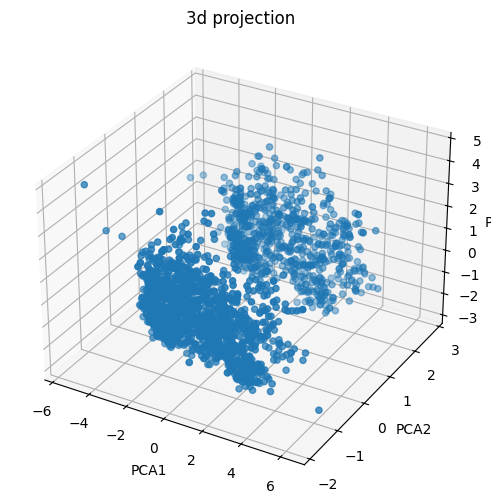

In [197]:
# plot
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

## The K value 

### 1 elbow method

In [200]:
wcss = []

for k in range(1,11):
    kmeans=KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

Text(0, 0.5, 'WCSS')

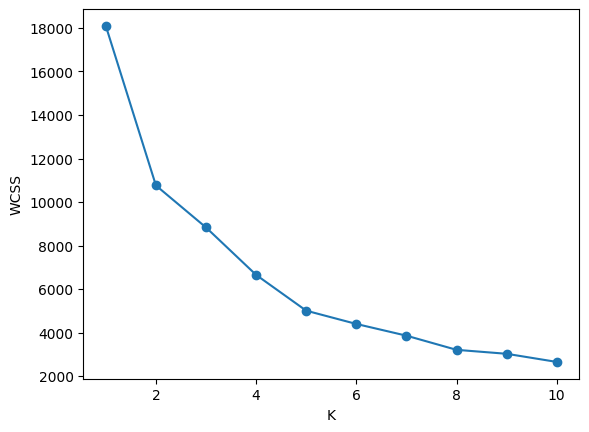

In [201]:
# plot

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")

### 2. Silhouette Score

In [206]:
scores =[]

for k in range(2,11):
    kmeans=KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca,labels)
    scores.append(score)

Text(0, 0.5, 'ss')

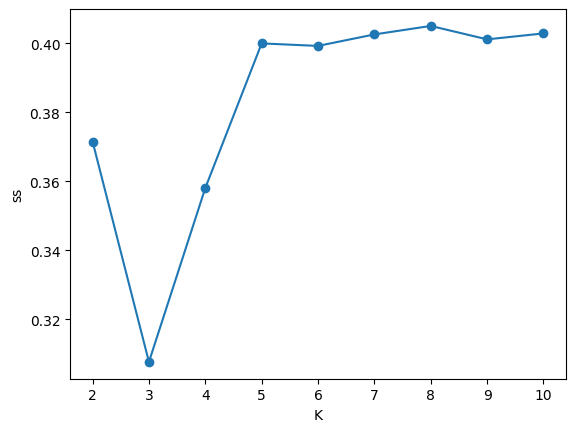

In [207]:
# plot

plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("K")
plt.ylabel("ss")

Text(0, 0.5, 'SS')

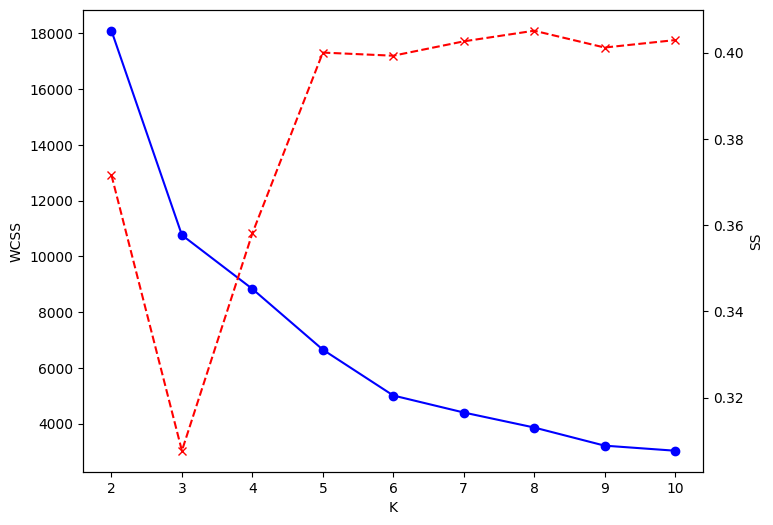

In [208]:
k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue") 
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("SS")

In [227]:
from kneed import KneeLocator

knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

print("optimal k =",knee.elbow)

optimal k = 4


## Clustering

### 1 K-means

In [211]:
k = 4

kmeans = KMeans(n_clusters=k,random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

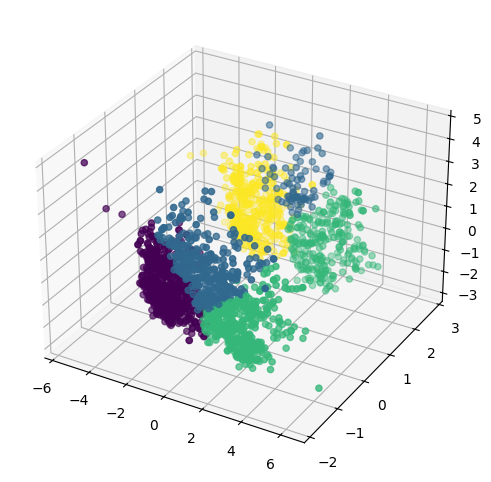

In [212]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_kmeans)

### 2 Agglomerative Clustering

In [213]:
agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)

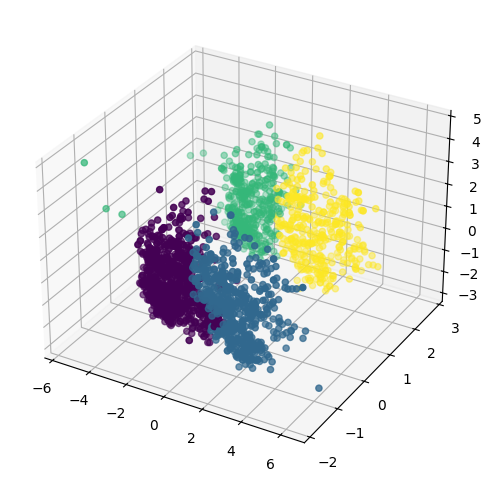

In [214]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg)

## Characterization of Clusters

In [215]:
X['clusters'] = labels_agg

In [216]:
X.head()

,income,recency,numdealspurchases,numwebpurchases,numcatalogpurchases,numstorepurchases,numwebvisitsmonth,complain,response,cutomer_tenure,age,total_spending,total_children,education_Graduate,education_PostGraduate,education_UnderGraduate,living_with_Alone,living_with_Partner,clusters
0,58138.0,58,3,8,10,4,7,0,1,663,69,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,113,72,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,312,61,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,139,42,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,161,45,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='clusters', ylabel='count'>

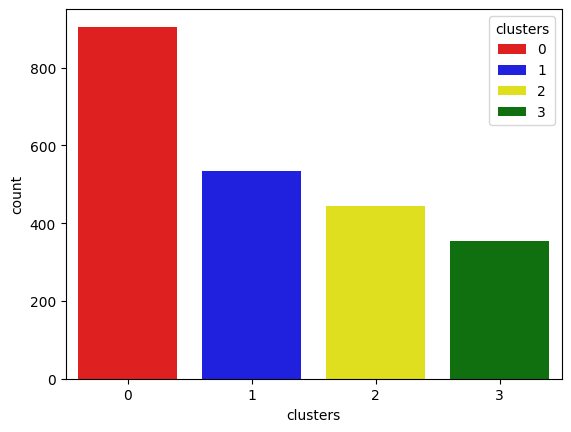

In [219]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=X["clusters"], palette=pal, hue=X["clusters"])

<Axes: xlabel='total_spending', ylabel='income'>

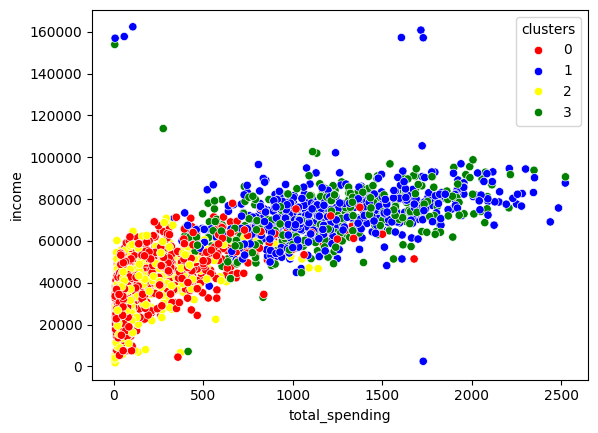

In [221]:
# Income & Spending patterns

sns.scatterplot(x=X["total_spending"], y=X["income"], hue=X["clusters"], palette=pal)

In [223]:
# Cluster Summary

cluster_summary = X.groupby("clusters").mean()
print(cluster_summary)

                income    recency  numdealspurchases  numwebpurchases  \
clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          numcatalogpurchases  numstorepurchases  numwebvisitsmonth  complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          response  cutomer_tenure        age  total_spending  total_child